# 05 — Why does the edge work on some assets and bleed on others?

nb03 showed a stark split: BTC/ETH win, most alts lose, with a 'survivor vs corpse' pattern. The question: **why doesn't the edge spread to everyone?** The user's framing is right to be skeptical — you can't blame *half the market* on 'an informed participant making the asset weird'. So let's find the real, measurable mechanism.

**Approach.** Decompose per-asset PnL by side (long/short), then relate the outcome to *measurable properties of each coin* — its trend/regime mix, its volatility, and above all **how mean-reverting vs trending its intraday returns are** (lag-1 autocorrelation, variance ratio). If the edge is mechanically mean-reversion, it should generalize **exactly as far as an asset is mean-reverting** — no conspiracy needed.

**Prediction.** (1) It is NOT the direction/regime mix (winners and losers should trade a similar long/short blend). (2) The short side is the structural weak point. (3) The per-asset outcome grades with the asset's *character*: more mean-reverting + lower-vol → wins; more trending/breakout + higher-vol → the stop-less MR (esp. shorts) gets run over.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from pathlib import Path
START, END = "2024-01-01", "2026-01-01"
CACHE = Path("_out/05_mr_split.parquet")

if CACHE.exists():
    d = pd.read_parquet(CACHE)
    print("loaded cache:", len(d), "symbols")
else:
    uni = pd.read_parquet("_out/03_universe_full.parquet")
    rows = []
    for s in uni.symbol:
        try: df = ohlcv(s, START, END, "1h")
        except Exception: continue
        if len(df) < 500: continue
        tr = backtest(strat_signals(df, s), df["close"])
        t = tr["trades"]
        if t.empty: continue
        lp, sp = t[t.dir == 1]["pnl"], t[t.dir == -1]["pnl"]
        ret = df["close"].pct_change().dropna()
        ema = df["close"].ewm(span=200, adjust=False).mean()
        rows.append(dict(symbol=s, long_pnl=float(lp.sum()), short_pnl=float(sp.sum()),
            n_long=len(lp), n_short=len(sp),
            long_win=float((lp > 0).mean()) if len(lp) else np.nan,
            short_win=float((sp > 0).mean()) if len(sp) else np.nan,
            total=float(tr["total_return"]), buyhold=float(df["close"].iloc[-1]/df["close"].iloc[0]-1),
            frac_up=float((df["close"] > ema).mean()), ann_vol=float(ret.std()*np.sqrt(8766)),
            ac1=float(ret.autocorr(1)),
            vr6=float(df["close"].pct_change(6).dropna().var()/(6*ret.var()))))
    d = pd.DataFrame(rows); d.to_parquet(CACHE)
    print("computed + cached:", len(d), "symbols")

loaded cache: 148 symbols


## Step 1 — refute the easy explanations: it is NOT the direction mix or the regime

Split symbols into winners (strategy > 0) vs losers and compare *how they trade*.

In [2]:
grp = d.assign(grp=np.where(d.total > 0, "WINNERS", "LOSERS")).groupby("grp").agg(
    n=("symbol", "size"),
    long_pnl=("long_pnl", "mean"), long_win=("long_win", "mean"),
    short_pnl=("short_pnl", "mean"), short_win=("short_win", "mean"),
    n_long=("n_long", "mean"), n_short=("n_short", "mean"),
    frac_up=("frac_up", "mean"), buyhold=("buyhold", "mean"),
    ann_vol=("ann_vol", "mean"), ac1=("ac1", "mean"), vr6=("vr6", "mean"),
).round(3)
print("aggregate side PnL:  long total", round(d.long_pnl.sum(), 2),
      "| short total", round(d.short_pnl.sum(), 2), " (short = the net drag)")
grp.T

aggregate side PnL:  long total 3.43 | short total -5.23  (short = the net drag)


grp,LOSERS,WINNERS
n,92.000,56.000
long_pnl,-0.032,0.114
long_win,0.618,0.663
short_pnl,-0.130,0.120
short_win,0.612,0.671
n_long,34.196,35.339
n_short,57.630,58.911
frac_up,0.427,0.421
buyhold,-0.507,-0.092
ann_vol,1.083,1.076


[saved] notebooks\pivots\_out\05_side_split.png


WindowsPath('C:/projects/researchlab/notebooks/pivots/_out/05_side_split.png')

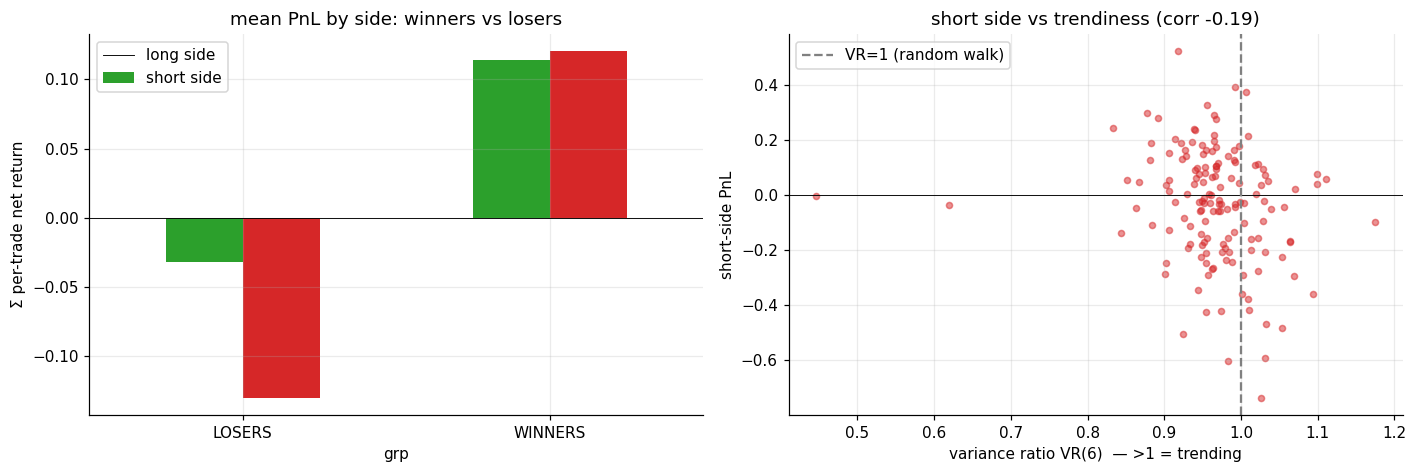

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
g = d.assign(grp=np.where(d.total > 0, "WINNERS", "LOSERS"))
means = g.groupby("grp")[["long_pnl", "short_pnl"]].mean()
means.plot(kind="bar", ax=ax1, color=["#2ca02c", "#d62728"], rot=0)
ax1.axhline(0, color="k", lw=0.6); ax1.set_title("mean PnL by side: winners vs losers")
ax1.set_ylabel("Σ per-trade net return"); ax1.legend(["long side", "short side"])
# the short side vs how trending the coin is
ax2.scatter(d.vr6, d.short_pnl, s=16, alpha=0.5, color="#d62728")
ax2.axhline(0, color="k", lw=0.6); ax2.axvline(1.0, color="gray", ls="--", label="VR=1 (random walk)")
ax2.set_xlabel("variance ratio VR(6)  — >1 = trending"); ax2.set_ylabel("short-side PnL")
ax2.set_title(f"short side vs trendiness (corr {d.vr6.corr(d.short_pnl):+.2f})"); ax2.legend()
show("05_side_split")

## Step 2 — the real discriminator: the asset's mean-reversion character

Grade every alt by lag-1 return autocorrelation (more negative = more mean-reverting) and by variance ratio, and see how the strategy does across the spectrum.

In [4]:
print("correlations of strategy return with coin character:")
for c in ["ann_vol", "vr6", "ac1", "buyhold", "frac_up"]:
    print(f"  corr(total, {c:8}) = {d.total.corr(d[c]):+.3f}")
d["acq"] = pd.qcut(d.ac1, 4, labels=["Q1 most MR", "Q2", "Q3", "Q4 most trending"])
q = d.groupby("acq", observed=True).agg(n=("symbol", "size"),
    strat_ret_pct=("total", lambda x: round(x.mean()*100, 1)),
    pct_profit=("total", lambda x: round((x > 0).mean()*100)),
    short_pnl=("short_pnl", lambda x: round(x.mean(), 3)),
    ann_vol=("ann_vol", lambda x: round(x.mean(), 2)),
    ac1=("ac1", lambda x: round(x.mean(), 3)))
q

correlations of strategy return with coin character:
  corr(total, ann_vol ) = -0.198
  corr(total, vr6     ) = -0.176
  corr(total, ac1     ) = -0.122
  corr(total, buyhold ) = +0.047
  corr(total, frac_up ) = +0.013


,n,strat_ret_pct,pct_profit,short_pnl,ann_vol,ac1
acq,,,,,,
Q1 most MR,37,-2.5,43,0.012,1.04,-0.042
Q2,37,-3.8,49,-0.005,1.05,-0.012
Q3,37,-9.2,38,-0.048,1.12,-0.002
Q4 most trending,37,-17.3,22,-0.100,1.11,0.017


[saved] notebooks\pivots\_out\05_mr_gradient.png


WindowsPath('C:/projects/researchlab/notebooks/pivots/_out/05_mr_gradient.png')

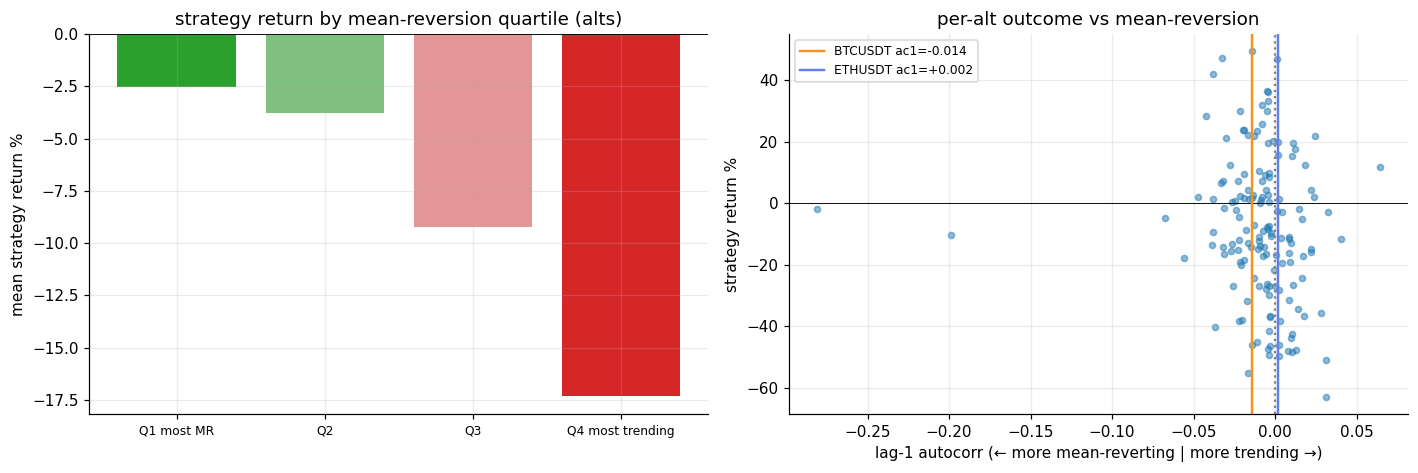

In [5]:
# where do BTC/ETH sit on the mean-reversion spectrum?
majors = {}
for s in ["BTCUSDT", "ETHUSDT"]:
    df = ohlcv(s, START, END, "1h"); ret = df["close"].pct_change().dropna()
    majors[s] = float(ret.autocorr(1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
qq = d.groupby("acq", observed=True)["total"].mean() * 100
ax1.bar(range(4), qq.values, color=["#2ca02c", "#7fbf7f", "#e39696", "#d62728"])
ax1.set_xticks(range(4)); ax1.set_xticklabels(qq.index, fontsize=8)
ax1.axhline(0, color="k", lw=0.6); ax1.set_ylabel("mean strategy return %")
ax1.set_title("strategy return by mean-reversion quartile (alts)")
ax2.scatter(d.ac1, d.total * 100, s=16, alpha=0.5, color="#1f77b4")
ax2.axhline(0, color="k", lw=0.6); ax2.axvline(0, color="gray", ls=":")
for s, c in [("BTCUSDT", "#f7931a"), ("ETHUSDT", "#627eea")]:
    ax2.axvline(majors[s], color=c, lw=1.6, label=f"{s} ac1={majors[s]:+.3f}")
ax2.set_xlabel("lag-1 autocorr (← more mean-reverting | more trending →)")
ax2.set_ylabel("strategy return %"); ax2.set_title("per-alt outcome vs mean-reversion"); ax2.legend(fontsize=8)
show("05_mr_gradient")

## Verdict — no 'informed participant' needed: the edge is mean-reversion, and it generalizes only as far as an asset mean-reverts

**Step 1 killed the easy explanations.** Winners and losers trade an almost *identical* blend — same time above EMA200 (frac_up 0.42 vs 0.43), same long/short mix (~35 long / 58 short), even the same lag-1 autocorr and variance ratio at the group level. So it is **not** the direction mix, not 'how long the coin was in an up-trend', not a regime-timing failure. What differs: the **loser coins collapsed far more** (buy&hold −51% vs −9%), and crucially **both sides fail together** on losers (long −0.03, short −0.13) while both win on winners (+0.11/+0.12). The **short side is the structural drag** — aggregated across the universe long PnL is +3.4 but short is −5.2, and the losers' short leg (−0.13) is the single worst line.

**Step 2 found the real, measurable gradient — the asset's mean-reversion character.** Grade alts by lag-1 autocorrelation and the strategy return falls monotonically:\n\n| quartile | strat ret | % profitable | short-side PnL | ac1 |\n|---|---|---|---|---|\n| Q1 most mean-reverting | −2.5% | 43% | **+0.012** | −0.042 |\n| Q2 | −3.8% | 49% | −0.005 | −0.012 |\n| Q3 | −9.2% | 38% | −0.048 | −0.002 |\n| Q4 most trending | **−17.3%** | **22%** | **−0.100** | +0.017 |\n\nThe damage is concentrated exactly where theory says: on **trending / breakout-prone** coins the short-side PnL goes from +0.01 to −0.10. That is the mechanism — `pivot_cci` is **stop-less mean-reversion**: it shorts pokes above R1 and buys pokes below S1 betting they revert to P. On a mean-reverting asset the poke fades (win). On a trending/breakout asset the poke **continues**, and with no hard stop the position gets run over — a fat left tail that a 60%+ win-rate cannot pay for. Volatility is the amplifier (corr(total, vol) = **−0.20**, the strongest single factor): higher vol = bigger tail when reversion fails.

**Why BTC/ETH are the champions.** BTC is genuinely mean-reverting (more MR than ~2/3 of alts); ETH is middling on intraday autocorr but was carried by the **EMA200 gate + its own strong up-trend** and by deep liquidity (smaller idiosyncratic breakout tails). The harness didn't pick BTC/ETH by luck — it selected the names that sit on the favorable side of this gradient.

### The answer to the question
There is **no broad edge 'failing to spread'**, and no need for an informed-participant story. The edge is **narrow by construction**: mean-reversion-in-trend. Its per-asset payoff is a continuous function of that asset's character — *does it mean-revert or break out, how violent is its vol, is it collapsing*. Those properties vary smoothly across the whole market, so **~half the universe landing on the unfavorable side is expected, not anomalous**. The fragile piece is the **stop-less short leg**, which trending coins systematically exploit.

**Honest caveats.** All correlations are weak individually (−0.12 to −0.20) — there is *no single clean flag*, which is itself the point (a spectrum, not a switch). Full window dominated by the 2024–26 alt bear (even Q1 is slightly negative). Autocorr/VR are noisy per-symbol estimates. This is the notebook lens, not the harness.

**Bridge to the next idea (win-rate).** The user's instinct — 'raise win-rate and the losers recover' — targets the right symptom (losers win 61% vs winners 67%) but likely the wrong lever: with MR the tail, not the hit-rate, is what sinks the losers, and win-rate/expectancy famously decouple (the pump line found an 83%-win, negative-expectancy rule). Next notebook tests it directly: can any win-rate-raising change actually lift the losing symbols, or does it just trade the win-rate trap? The theory-preferred fixes are instead **(a) skip trending/high-vol coins** (this notebook) and **(b) cap the tail with a stop** / drop the short leg.